In [7]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

play = pd.read_csv("Play Store Data.csv")

In [11]:
play = play.drop_duplicates(subset="App")
play = play.reset_index(drop=True)
play = play[play["Category"] != "1.9"]

In [16]:
play["Reviews"] = pd.to_numeric(
    play["Reviews"],
    errors="coerce"
)
play["Rating"] = pd.to_numeric(
    play["Rating"],
    errors="coerce"
)
play["Installs"] = (
    play["Installs"]
    .astype(str)
    .str.replace(",", "")
    .str.replace("+", "")
)

play["Installs"] = pd.to_numeric(
    play["Installs"],
    errors="coerce"
)

In [19]:
play["Size"] = play["Size"].astype(str)
def convert_size(size):

    if "M" in size:
        return float(size.replace("M", ""))

    elif "k" in size:
        return float(size.replace("k", "")) / 1024

    else:
        return np.nan

play["Size_MB"] = play["Size"].apply(convert_size)

In [23]:
df = play[
    play["Rating"] >= 4.2
]
df = df[
    df["Reviews"] > 1000
]

df = df[
    (df["Size_MB"] >= 20)
    &
    (df["Size_MB"] <= 80)
]

In [26]:
df = df[
    df["Category"]
    .str.startswith(
        ("T", "P"),
        na=False
    )
]
df = df[
    ~df["App"]
    .str.contains(
        r"\d",
        regex=True,
        na=False
    )
]

In [28]:
df["Category"] = df["Category"].replace({

    "TRAVEL_AND_LOCAL":"Voyage et Local",

    "PRODUCTIVITY":"Productividad",

    "PHOTOGRAPHY":"写真"

})

In [31]:
df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

df["Month"] = (
    df["Last Updated"]
    .dt.to_period("M")
    .astype(str)
)

In [33]:
trend = (
    df.groupby(
        ["Month","Category"]
    )["Installs"]
    .sum()
    .reset_index()
)

In [35]:
trend["MoM_Growth"] = (
    trend.groupby("Category")
    ["Installs"]
    .pct_change()
)

In [37]:
growth = trend[
    trend["MoM_Growth"] > 0.25
]

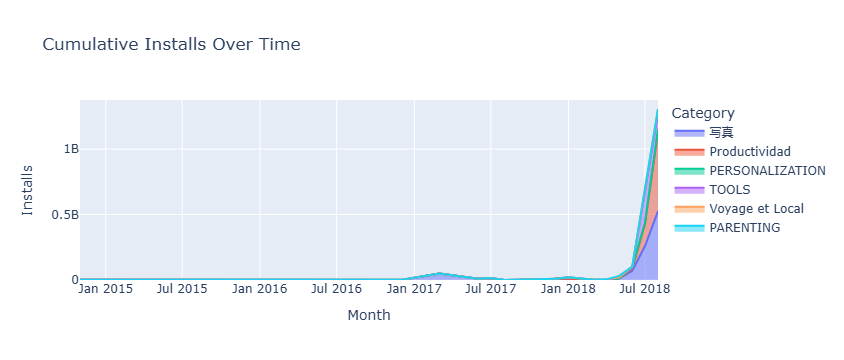

In [41]:
fig = px.area(

    trend,

    x="Month",

    y="Installs",

    color="Category",

    title="Cumulative Installs Over Time"

)
fig.show()

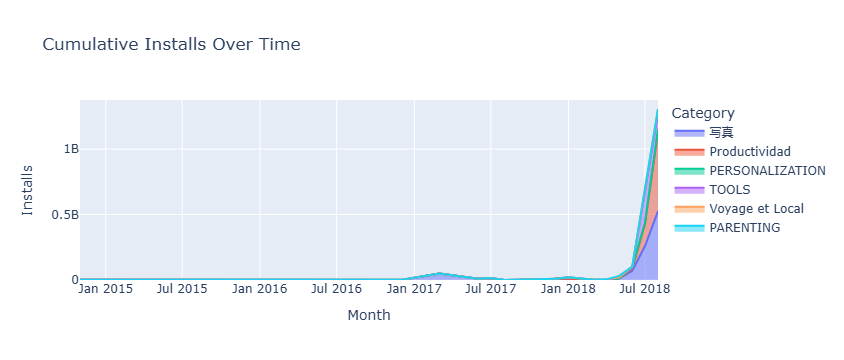

In [44]:
for _, row in growth.iterrows():

    fig.add_vrect(

        x0=row["Month"],

        x1=row["Month"],

        fillcolor="yellow",

        opacity=0.25,

        line_width=0

    )
fig.show()

In [46]:
from datetime import datetime
import pytz

india = pytz.timezone("Asia/Kolkata")
now = datetime.now(india)

if 16 <= now.hour < 18:

    fig.show()

else:

    print(
        "This visualization is available only between 4 PM IST and 6 PM IST."
    )

This visualization is available only between 4 PM IST and 6 PM IST.


In [47]:
fig.write_html(
    "stacked_area_dashboard.html",
    include_plotlyjs="cdn"
)